In [1]:
import os
import random
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

from pathlib import Path
from datasets import Dataset

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

c:\Users\user1\miniconda3\envs\nlp-gpu\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("="*50)
print("CUDA Available :", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU :", torch.cuda.get_device_name(0))

    print(
        "VRAM :",
        round(
            torch.cuda.get_device_properties(0).total_memory
            /1024**3,
            2
        ),
        "GB"
    )

print("="*50)

CUDA Available : True
GPU : NVIDIA GeForce RTX 2050
VRAM : 4.0 GB


In [3]:
CORPUS_SIZE = 3

DATASET_MAP = {
    1: "10k",
    2: "20k",
    3: "30k",
    4: "40k",
    5: "full"
}

if CORPUS_SIZE not in DATASET_MAP:
    raise ValueError("CORPUS_SIZE harus antara 1-5")

DATASET_NAME = DATASET_MAP[CORPUS_SIZE]

DATA_DIR = f"dataset/preprocessed/{DATASET_NAME}"

print(f"Dataset : {DATASET_NAME}")
print(f"Folder  : {DATA_DIR}")

Dataset : 30k
Folder  : dataset/preprocessed/30k


In [4]:
train_df = pd.read_csv(
    f"{DATA_DIR}/train_bert.csv"
)

test_df = pd.read_csv(
    f"{DATA_DIR}/test_bert.csv"
)

print("Train Shape :", train_df.shape)
print("Test Shape  :", test_df.shape)

train_df.head()

Train Shape : (24000, 2)
Test Shape  : (6000, 2)


,text,label
0,coo twitter ali rowghani meninggalkan perusahaan,0
1,vietnam berupaya membungkam protes anti-beijin...,0
2,film fitur aksi langsung power rangers diumumkan,1
3,valuasi sebesar 18$ miliar untuk aplikasi taks...,0
4,"penghargaan musik billboard: nicki minaj, kend...",1


In [5]:
train_ds = Dataset.from_pandas(
    train_df
)

test_ds = Dataset.from_pandas(
    test_df
)

print(train_ds)
print(test_ds)

Dataset({
    features: ['text', 'label'],
    num_rows: 24000
})
Dataset({
    features: ['text', 'label'],
    num_rows: 6000
})


In [6]:
import joblib

le = joblib.load(
    "dataset/preprocessed/label_encoder.pkl"
)

class_names = list(le.classes_)
NUM_LABELS = len(class_names)

print(class_names)

['Economy', 'Entertainment', 'Technology']


c:\Users\user1\miniconda3\envs\nlp-gpu\lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator LabelEncoder from version 1.6.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [7]:
from transformers import AutoTokenizer

MODEL_NAME = "indobenchmark/indobert-base-p1"

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME,
    use_fast=False
)

print("Tokenizer Loaded!")

Tokenizer Loaded!


In [8]:
MAX_LENGTH = 64

def tokenize(batch):

    return tokenizer(
        batch["text"],
        truncation=True,
        padding="max_length",
        max_length=MAX_LENGTH
    )

train_ds = train_ds.map(
    tokenize,
    batched=True
)

test_ds = test_ds.map(
    tokenize,
    batched=True
)

print("Tokenization Completed!")

Map: 100%|██████████| 6000/6000 [00:02<00:00, 2921.41 examples/s]

Tokenization Completed!


In [9]:
train_ds.set_format(
    type="torch",
    columns=[
        "input_ids",
        "attention_mask",
        "label"
    ]
)

test_ds.set_format(
    type="torch",
    columns=[
        "input_ids",
        "attention_mask",
        "label"
    ]
)

print("Dataset Ready!")

Dataset Ready!


In [10]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    ignore_mismatched_sizes=True
)

print("Model Loaded!")

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at indobenchmark/indobert-base-p1 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model Loaded!


In [11]:
def compute_metrics(eval_pred):

    logits, labels = eval_pred

    preds = np.argmax(
        logits,
        axis=1
    )

    return {
        "accuracy": accuracy_score(
            labels,
            preds
        ),

        "precision": precision_score(
            labels,
            preds,
            average="macro",
            zero_division=0
        ),

        "recall": recall_score(
            labels,
            preds,
            average="macro",
            zero_division=0
        ),

        "f1": f1_score(
            labels,
            preds,
            average="macro",
            zero_division=0
        )
    }

In [12]:
training_args = TrainingArguments(
    output_dir=f"models/skenario 4/checkpoints/indobert_{DATASET_NAME}",

    evaluation_strategy="epoch",
    save_strategy="epoch",

    load_best_model_at_end=True,
    metric_for_best_model="f1",

    learning_rate=2e-5,
    weight_decay=0.01,

    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,

    gradient_accumulation_steps=8,

    num_train_epochs=3,

    fp16=True,

    logging_steps=100,
    save_total_limit=2,

    report_to="none"
)

c:\Users\user1\miniconda3\envs\nlp-gpu\lib\site-packages\transformers\training_args.py:1568: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


In [13]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=test_ds,
    compute_metrics=compute_metrics
)

print("Trainer Ready!")

Trainer Ready!


In [14]:
train_result = trainer.train()

print()
print("Training Completed!")

  2%|▏         | 100/4500 [01:38<51:58,  1.41it/s] 

{'loss': 0.5605, 'grad_norm': 76.46208190917969, 'learning_rate': 1.9560000000000002e-05, 'epoch': 0.07}


  4%|▍         | 200/4500 [02:45<44:28,  1.61it/s]

{'loss': 0.385, 'grad_norm': 60.639583587646484, 'learning_rate': 1.912e-05, 'epoch': 0.13}


  7%|▋         | 300/4500 [03:50<44:14,  1.58it/s]

...

{'loss': 0.1117, 'grad_norm': 17.916709899902344, 'learning_rate': 1.777777777777778e-08, 'epoch': 3.0}


                                                   
100%|██████████| 4500/4500 [53:11<00:00,  1.59it/s]

{'eval_loss': 0.34631332755088806, 'eval_accuracy': 0.9386666666666666, 'eval_precision': 0.9352974494614239, 'eval_recall': 0.9339385664916354, 'eval_f1': 0.934592541179911, 'eval_runtime': 63.954, 'eval_samples_per_second': 93.817, 'eval_steps_per_second': 46.909, 'epoch': 3.0}


100%|██████████| 4500/4500 [53:14<00:00,  1.41it/s]

{'train_runtime': 3194.7443, 'train_samples_per_second': 22.537, 'train_steps_per_second': 1.409, 'train_loss': 0.20920615747239854, 'epoch': 3.0}

Training Completed!


In [15]:
predictions = trainer.predict(
    test_ds
)

y_pred = np.argmax(
    predictions.predictions,
    axis=1
)

y_true = predictions.label_ids

print(
    "Total Test Data:",
    len(y_true)
)

100%|██████████| 3000/3000 [01:02<00:00, 48.29it/s]

Total Test Data: 6000


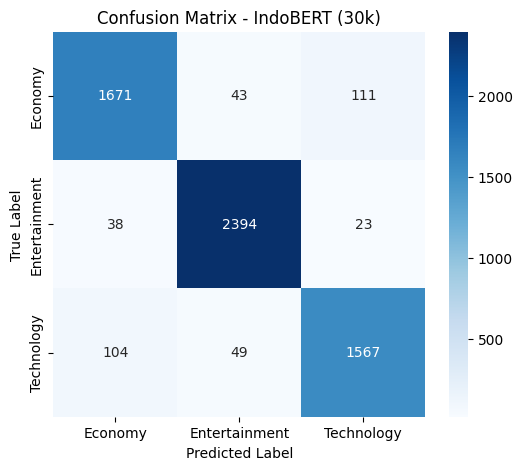

In [16]:
cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(
    figsize=(6,5)
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel(
    "Predicted Label"
)

plt.ylabel(
    "True Label"
)

plt.title(
    f"Confusion Matrix - IndoBERT ({DATASET_NAME})"
)

plt.show()

In [17]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        zero_division=0
    )
)

               precision    recall  f1-score   support

      Economy       0.92      0.92      0.92      1825
Entertainment       0.96      0.98      0.97      2455
   Technology       0.92      0.91      0.92      1720

     accuracy                           0.94      6000
    macro avg       0.94      0.93      0.93      6000
 weighted avg       0.94      0.94      0.94      6000



In [18]:
acc = accuracy_score(
    y_true,
    y_pred
)

prec = precision_score(
    y_true,
    y_pred,
    average="macro"
)

rec = recall_score(
    y_true,
    y_pred,
    average="macro"
)

f1 = f1_score(
    y_true,
    y_pred,
    average="macro"
)

print()
print("=== IndoBERT ===")
print()

print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-Score : {f1:.4f}")


=== IndoBERT ===

Accuracy : 0.9387
Precision: 0.9353
Recall   : 0.9339
F1-Score : 0.9346


In [19]:
import os
import pandas as pd

os.makedirs(
    "results/training",
    exist_ok=True
)

RESULT_FILE = (
    "results/training/indobert_results.csv"
)

new_result = pd.DataFrame([
    {
        "Model": "IndoBERT",
        "Dataset": DATASET_NAME,
        "Train_Size": len(train_df),
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-Score": f1
    }
])

if os.path.exists(RESULT_FILE):

    previous = pd.read_csv(
        RESULT_FILE
    )

    result = pd.concat(
        [
            previous,
            new_result
        ],
        ignore_index=True
    )

    result = result.drop_duplicates(
        subset=[
            "Model",
            "Dataset"
        ],
        keep="last"
    )

else:

    result = new_result

result = result.sort_values(
    by="Train_Size"
)

result.to_csv(
    RESULT_FILE,
    index=False
)

print()
print(result)


      Model Dataset  Train_Size  Accuracy  Precision    Recall  F1-Score
0  IndoBERT     10k        8000  0.907500   0.902627  0.900541  0.901503
1  IndoBERT     20k       16000  0.930000   0.926162  0.925004  0.925557
3  IndoBERT     30k       24000  0.938667   0.935297  0.933939  0.934593
2  IndoBERT    full       38963  0.940458   0.936602  0.936158  0.936377


In [20]:
SAVE_PATH = f"models/skenario 4/indobert_{DATASET_NAME}"

os.makedirs(SAVE_PATH, exist_ok=True)

trainer.save_model(SAVE_PATH)
tokenizer.save_pretrained(SAVE_PATH)

print("Model Saved!")
print(SAVE_PATH)

Model Saved!
models/skenario 4/indobert_30k
